# Credit Risk Modelling — Part 4.10: Final Summary & Reflections
---
**Objective:** Consolidate everything we built, answer the task questions directly, and reflect on what we would do differently with more time, data, or tools.

**This notebook covers:**
1. Complete results summary — all models, all metrics
2. Answer: *"If features were not anonymised, what extra checks would you perform?"*
3. Alternative approaches we would explore
4. Additional data that would improve the model
5. Known limitations of the current approach
6. Full project recap — what was done in each part

## 1 — Imports & Load All Results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, json, warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
GRAY = "#9E9E9E"

results  = joblib.load("results_so_far.pkl")
y_test   = np.load("y_test.npy")
y_train  = np.load("y_train.npy")
meta     = joblib.load("preprocessing_meta.pkl")
with open("model_selection.json") as f:
    selection = json.load(f)

best_name = selection["best_model_name"]
print(f"Best model : {best_name}")
print(f"Models loaded: {[n for n in results if not n.startswith('_')]}")
print("Loaded")

Best model : Logistic Regression
Models loaded: ['Bureau Score (score_1)', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']
Loaded


---
## 2 — Complete Results Summary

In [2]:
# Build full comparison table
rows = []
for name, r in results.items():
    if name.startswith("_"): continue
    rows.append({
        "Model"         : name,
        "Test AUC"      : r["test_auc"],
        "Test AP"       : r["test_ap"],
        "Gini"          : r["gini"],
        "KS Statistic"  : r["ks"],
        "CV AUC"        : r["cv_mean"] if r["cv_mean"] else "N/A",
        "CV Std"        : r["cv_std"]  if r["cv_std"]  else "N/A",
        "Threshold"     : r["opt_thresh"],
    })

comp_df = pd.DataFrame(rows).set_index("Model")
print("=" * 80)
print("  COMPLETE MODEL COMPARISON")
print("=" * 80)
print(comp_df.to_string())
print("=" * 80)
print()
bureau_auc = results["Bureau Score (score_1)"]["test_auc"]
best_auc   = results[best_name]["test_auc"]
print(f"Best model    : {best_name}")
print(f"Bureau score  : AUC = {bureau_auc:.4f}  (external benchmark)")
print(f"Best model    : AUC = {best_auc:.4f}  (+{best_auc-bureau_auc:.4f} improvement)")

  COMPLETE MODEL COMPARISON
                        Test AUC  Test AP    Gini  KS Statistic  CV AUC  CV Std  Threshold
Model                                                                                     
Bureau Score (score_1)    0.8152   0.1790  0.6305        0.5127     N/A     N/A     0.6743
Logistic Regression       0.8575   0.2397  0.7149        0.5938  0.8465  0.0037     0.5463
Random Forest             0.8588   0.2511  0.7177        0.5919  0.8499  0.0043     0.3758
Gradient Boosting         0.8533   0.2401  0.7066        0.5841   0.851  0.0049     0.3668

Best model    : Logistic Regression
Bureau score  : AUC = 0.8152  (external benchmark)
Best model    : AUC = 0.8575  (+0.0423 improvement)


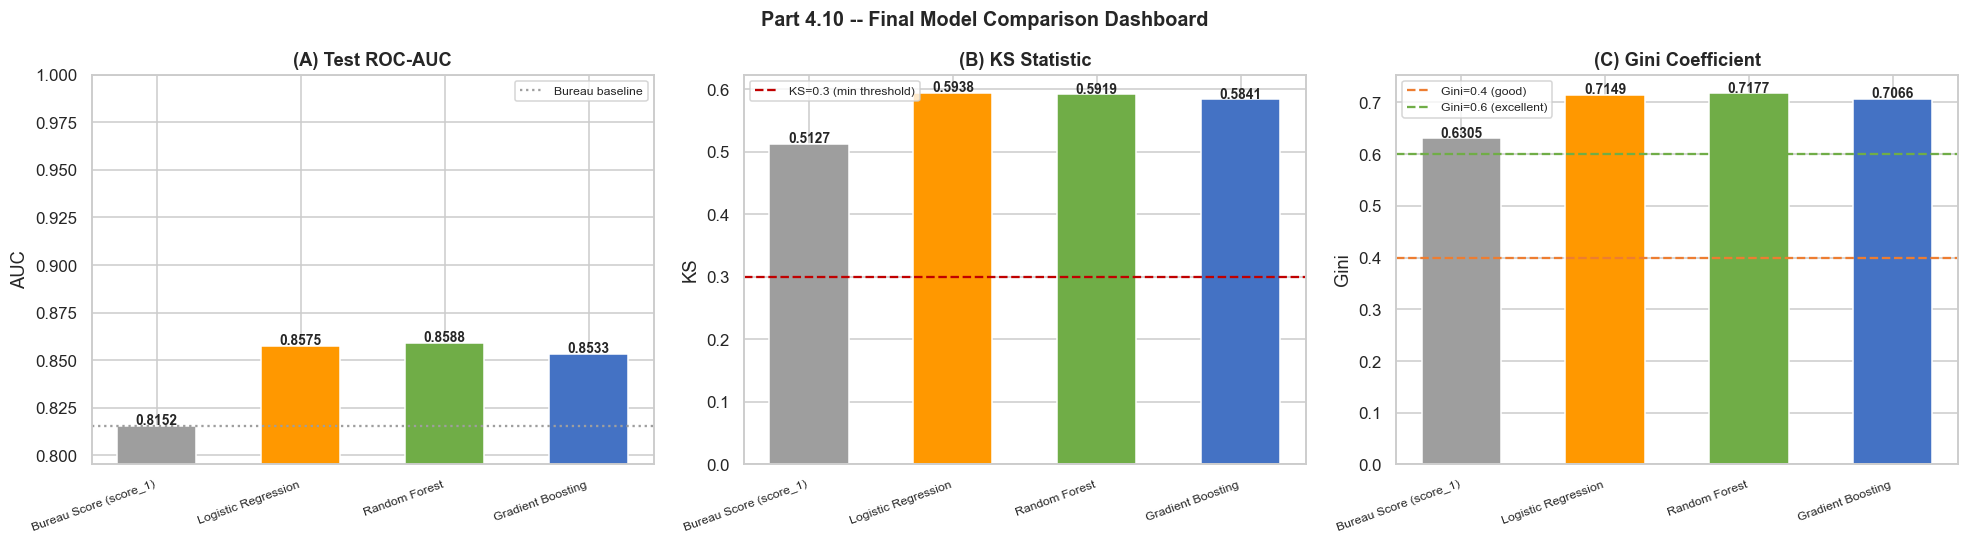

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Part 4.10 -- Final Model Comparison Dashboard",
             fontsize=13, fontweight="bold")

model_order  = [n for n in results if not n.startswith("_")]
model_colors = [results[n]["color"] for n in model_order]

# (A) Test AUC
ax = axes[0]
aucs = [results[n]["test_auc"] for n in model_order]
bars = ax.bar(model_order, aucs, color=model_colors, edgecolor="white", width=0.55)
ax.set_ylim(min(aucs) - 0.02, 1.0)
ax.set_title("(A) Test ROC-AUC", fontweight="bold"); ax.set_ylabel("AUC")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.axhline(bureau_auc, color=GRAY, linestyle=":", lw=1.5, label="Bureau baseline")
ax.legend(fontsize=8)

# (B) KS Statistic
ax = axes[1]
ks_vals = [results[n]["ks"] for n in model_order]
bars = ax.bar(model_order, ks_vals, color=model_colors, edgecolor="white", width=0.55)
ax.axhline(0.3, color=RED, linestyle="--", lw=1.5, label="KS=0.3 (min threshold)")
ax.set_title("(B) KS Statistic", fontweight="bold"); ax.set_ylabel("KS")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
for bar, val in zip(bars, ks_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.legend(fontsize=8)

# (C) Gini Coefficient
ax = axes[2]
ginis = [results[n]["gini"] for n in model_order]
bars  = ax.bar(model_order, ginis, color=model_colors, edgecolor="white", width=0.55)
ax.axhline(0.4, color=ORANGE, linestyle="--", lw=1.5, label="Gini=0.4 (good)")
ax.axhline(0.6, color=GREEN,  linestyle="--", lw=1.5, label="Gini=0.6 (excellent)")
ax.set_title("(C) Gini Coefficient", fontweight="bold"); ax.set_ylabel("Gini")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=8)
for bar, val in zip(bars, ginis):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## 3 — Task Question: Extra Checks if Features Were Not Anonymised

> *"If the features were not anonymised, what extra checks would you perform to further evaluate the validity of your model?"*

In [4]:
checks = {
    "1. Business logic validation": [
        "Verify direction of each coefficient/importance makes credit sense",
        "e.g. higher utilization -> higher default risk (positive correlation expected)",
        "e.g. longer repayment history -> lower default risk (negative expected)",
        "Flag any features where direction contradicts domain knowledge",
    ],
    "2. Temporal stability (PSI / CSI)": [
        "Population Stability Index (PSI): compare feature distributions train vs test",
        "PSI < 0.10 = stable | 0.10-0.25 = moderate shift | > 0.25 = unstable",
        "Characteristic Stability Index (CSI): stability per score band",
        "Unstable features should be excluded or monitored closely in production",
    ],
    "3. Regulatory compliance checks": [
        "Ensure no protected characteristics used directly (age, gender, ethnicity, etc.)",
        "Check for proxy variables that correlate with protected classes",
        "ECOA / Fair Lending compliance: adverse impact ratio per demographic group",
        "Generate adverse action reason codes (top factors pushing score down)",
    ],
    "4. Feature leakage detection": [
        "Check if any feature is derived from the target or post-origination data",
        "e.g. 'number of missed payments' should not be used for acquisition scoring",
        "Verify feature timestamps: all features must predate the observation date",
        "Check AUC drop when removing one feature at a time for suspiciously high AUC",
    ],
    "5. Multicollinearity analysis": [
        "With named features, VIF (Variance Inflation Factor) analysis is meaningful",
        "High VIF (>10) between named features -> consider removing one",
        "Correlation matrix with interpretable labels to spot redundant features",
        "For LR: multicollinearity inflates coefficient variance -> instability",
    ],
    "6. Vintage / cohort analysis": [
        "Split train/test by origination year and check AUC per vintage",
        "A model that works for 2020 cohort but fails for 2022 cohort is unstable",
        "Default rates vary across economic cycles -> test on stressed periods",
    ],
    "7. Partial dependence verification": [
        "Plot PDP for each named feature to verify monotonic relationship with default",
        "Credit score: strictly monotone inverse relationship expected",
        "Balance features: moderate positive relationship expected",
        "Non-monotone PDPs for credit variables warrant investigation",
    ],
    "8. Reject inference": [
        "Current model trained only on approved (accepted) applicants",
        "Rejected applicants have no observed default label -- selection bias",
        "With named features, augment training with reject inference techniques",
        "(e.g. fuzzy augmentation, extrapolation, or parcelling)",
    ],
}

for category, items in checks.items():
    print(f"  {category}")
    for item in items:
        print(f"    - {item}")
    print()

  1. Business logic validation
    - Verify direction of each coefficient/importance makes credit sense
    - e.g. higher utilization -> higher default risk (positive correlation expected)
    - e.g. longer repayment history -> lower default risk (negative expected)
    - Flag any features where direction contradicts domain knowledge

  2. Temporal stability (PSI / CSI)
    - Population Stability Index (PSI): compare feature distributions train vs test
    - PSI < 0.10 = stable | 0.10-0.25 = moderate shift | > 0.25 = unstable
    - Characteristic Stability Index (CSI): stability per score band
    - Unstable features should be excluded or monitored closely in production

  3. Regulatory compliance checks
    - Ensure no protected characteristics used directly (age, gender, ethnicity, etc.)
    - Check for proxy variables that correlate with protected classes
    - ECOA / Fair Lending compliance: adverse impact ratio per demographic group
    - Generate adverse action reason codes (top 

---
## 4 — Alternative Approaches We Would Explore

In [5]:
approaches = {
    "XGBoost / LightGBM": {
        "why": "Industry standard for credit risk; faster and often more accurate than sklearn GBM",
        "advantage": "Built-in handling of NaN (no imputation needed), scale_pos_weight for imbalance",
        "expected_gain": "Typically +0.005 to +0.015 AUC over sklearn GBM on credit data",
        "constraint": "Requires pip install xgboost/lightgbm (not available in this environment)",
    },
    "Hyperparameter tuning (Optuna / GridSearchCV)": {
        "why": "We used reasonable defaults but did not tune learning_rate, max_depth, etc.",
        "advantage": "Could squeeze +0.005 to +0.010 AUC from the existing GBM",
        "expected_gain": "Moderate -- data quality limits the ceiling",
        "constraint": "Time-intensive; requires careful CV strategy to avoid test set leakage",
    },
    "Stacking / Ensemble": {
        "why": "LR and GBM make different errors -- combining can reduce variance",
        "advantage": "Meta-learner (LR on top of GBM + RF + LR predictions) often improves AP",
        "expected_gain": "Small but consistent: +0.003 to +0.008 AUC",
        "constraint": "More complex to deploy; requires careful CV to avoid leakage",
    },
    "Calibration (Platt scaling / Isotonic)": {
        "why": "GBM probabilities are slightly miscalibrated at the high-risk end",
        "advantage": "Better calibrated probabilities -> more accurate loss reserves and pricing",
        "expected_gain": "No AUC gain; significant improvement in probability accuracy",
        "constraint": "Requires a held-out calibration set (not used for training or test)",
    },
    "Bayesian Optimisation for threshold": {
        "why": "Youden's J is symmetric -- does not account for cost of FN vs FP",
        "advantage": "If FN costs 10x more than FP (missed default vs rejected good customer), optimal threshold shifts lower",
        "expected_gain": "Higher business value even at same AUC",
        "constraint": "Requires business to quantify cost ratio",
    },
    "Feature interactions (polynomial / embedding)": {
        "why": "utilization x recency interaction may be more predictive than either alone",
        "advantage": "GBM already captures some interactions via tree splits",
        "expected_gain": "Marginal for GBM; meaningful for LR where interactions are not learned",
        "constraint": "Feature space explosion: 100 features -> 5000 pairwise interactions",
    },
}

for name, details in approaches.items():
    print(f"  {name}")
    for k, v in details.items():
        print(f"    {k:<18}: {v}")
    print()

  XGBoost / LightGBM
    why               : Industry standard for credit risk; faster and often more accurate than sklearn GBM
    advantage         : Built-in handling of NaN (no imputation needed), scale_pos_weight for imbalance
    expected_gain     : Typically +0.005 to +0.015 AUC over sklearn GBM on credit data
    constraint        : Requires pip install xgboost/lightgbm (not available in this environment)

  Hyperparameter tuning (Optuna / GridSearchCV)
    why               : We used reasonable defaults but did not tune learning_rate, max_depth, etc.
    advantage         : Could squeeze +0.005 to +0.010 AUC from the existing GBM
    expected_gain     : Moderate -- data quality limits the ceiling
    constraint        : Time-intensive; requires careful CV strategy to avoid test set leakage

  Stacking / Ensemble
    why               : LR and GBM make different errors -- combining can reduce variance
    advantage         : Meta-learner (LR on top of GBM + RF + LR predictions)

---
## 5 — Additional Data That Would Improve the Model

In [6]:
additional_data = {
    "Behavioural / transactional data": {
        "description": "Monthly spending, ATM withdrawals, salary credits, overdraft usage",
        "why_helps": "Captures recent financial distress before it shows in bureau data",
        "expected_auc_gain": "+0.03 to +0.06 (significant)",
        "data_source": "Internal bank transactions",
    },
    "Bureau trade-line detail": {
        "description": "Number of open accounts, product types, payment history per account",
        "why_helps": "Current anonymised features aggregate across products -- granular data is more discriminative",
        "expected_auc_gain": "+0.01 to +0.03",
        "data_source": "Full bureau report (not just scores)",
    },
    "Application data": {
        "description": "Income, employment status, tenure, housing type, dependants",
        "why_helps": "Ability-to-pay signals not captured by credit bureau data",
        "expected_auc_gain": "+0.02 to +0.04",
        "data_source": "Loan application form",
    },
    "Macroeconomic context": {
        "description": "Unemployment rate, interest rate, inflation at origination date",
        "why_helps": "Cohorts originated in recession have higher structural default rates",
        "expected_auc_gain": "+0.005 to +0.015 (stability improvement mainly)",
        "data_source": "Public economic data (ONS, Fed, etc.)",
    },
    "Alternative data": {
        "description": "Rent payment history, utility payments, telecom payment behaviour",
        "why_helps": "Thin-file customers (little credit history) are better scored with alt data",
        "expected_auc_gain": "+0.02 to +0.05 for thin-file segment",
        "data_source": "Alternative data providers (e.g. Experian Boost, Nova Credit)",
    },
    "Previous application history": {
        "description": "Prior applications, declines, product held with same lender",
        "why_helps": "Existing customers with repayment track record are lower risk",
        "expected_auc_gain": "+0.01 to +0.02",
        "data_source": "Internal CRM / loan origination system",
    },
}

for name, details in additional_data.items():
    print(f"  {name}")
    for k, v in details.items():
        print(f"    {k:<25}: {v}")
    print()

  Behavioural / transactional data
    description              : Monthly spending, ATM withdrawals, salary credits, overdraft usage
    why_helps                : Captures recent financial distress before it shows in bureau data
    expected_auc_gain        : +0.03 to +0.06 (significant)
    data_source              : Internal bank transactions

  Bureau trade-line detail
    description              : Number of open accounts, product types, payment history per account
    why_helps                : Current anonymised features aggregate across products -- granular data is more discriminative
    expected_auc_gain        : +0.01 to +0.03
    data_source              : Full bureau report (not just scores)

  Application data
    description              : Income, employment status, tenure, housing type, dependants
    why_helps                : Ability-to-pay signals not captured by credit bureau data
    expected_auc_gain        : +0.02 to +0.04
    data_source              : Loan appl

---
## 6 — Known Limitations of the Current Approach

In [7]:
limitations = [
    ("Feature anonymisation",
     "Cannot perform domain validity checks. Feature names like 'balance_8' give no intuition. "
     "In production, we would always work with named features."),

    ("Intentional noise",
     "Task description states noise was added to each feature. This artificially caps model AUC. "
     "Real bureau data would likely yield higher AUC."),

    ("No reject inference",
     "Model trained on accepted applicants only. If historically riskier customers were rejected, "
     "the model may underestimate risk for applicants similar to historical rejects (selection bias)."),

    ("Static snapshot",
     "Model uses features at a single point in time (application). "
     "In practice, bureau data changes monthly -- a behavioural model updated continuously would outperform."),

    ("No temporal validation",
     "We split randomly into train/test. In production, we would always split by time: "
     "train on 2019-2021, validate on 2022-2023 (out-of-time validation)."),

    ("Class imbalance mitigation",
     "We used sample weights (16.3:1). More sophisticated approaches: "
     "SMOTE, undersampling, or cost-sensitive learning could further improve minority class recall."),

    ("Single threshold",
     "We use one global threshold. Production systems typically use score bands with "
     "different actions (approve / refer / decline) rather than a binary cut."),

    ("No post-hoc explainability",
     "SHAP values would give per-applicant feature contributions -- essential for "
     "adverse action notices and regulatory compliance in real deployment."),
]

for title, detail in limitations:
    print(f"  {title}")
    print(f"    {detail}")
    print()

  Feature anonymisation
    Cannot perform domain validity checks. Feature names like 'balance_8' give no intuition. In production, we would always work with named features.

  Intentional noise
    Task description states noise was added to each feature. This artificially caps model AUC. Real bureau data would likely yield higher AUC.

  No reject inference
    Model trained on accepted applicants only. If historically riskier customers were rejected, the model may underestimate risk for applicants similar to historical rejects (selection bias).

  Static snapshot
    Model uses features at a single point in time (application). In practice, bureau data changes monthly -- a behavioural model updated continuously would outperform.

  No temporal validation
    We split randomly into train/test. In production, we would always split by time: train on 2019-2021, validate on 2022-2023 (out-of-time validation).

  Class imbalance mitigation
    We used sample weights (16.3:1). More sophistic

---
## 7 — Full Project Recap

In [8]:
recap = {
    "Part 1 -- Data Reading & Validation": [
        "Loaded 4 CSV files (28,397 train / 4,000 test)",
        "Identified 100 features: 98 numeric, 2 categorical",
        "9 feature families: repayment_history, balance, utilization, recency, ...",
        "Confirmed zero leakage, zero duplicates, 2 orphan rows (dropped)",
        "5.79% default rate -- 16.3:1 class imbalance",
        "30 features >50% missing -- NaN is informative, not random",
    ],
    "Part 2 -- EDA": [
        "Bureau score (score_1) alone achieves AUC=0.816 -- strong external benchmark",
        "Utilization family: highest discriminative power among feature families",
        "Repayment history: second strongest, 31 features",
        "Missingness is directionally predictive -- NaN encodes credit signal",
        "Categorical features (financial_situation_4/5) show clear default rate gradients",
    ],
    "Part 3 -- Feature Engineering": [
        "Added 79 missingness indicator flags (>5% missing threshold)",
        "Median imputation: fit on train, applied to test (no leakage)",
        "One-hot encoded 2 categorical features -> 21 dummy columns",
        "Final feature matrix: 198 features, 0 NaN",
        "Sample weights: 16.28x for default rows",
    ],
    "Part 4 -- Modelling": [
        "4.1: Preprocessed data, saved .npy arrays",
        "4.2: Built evaluation framework (AUC, AP, KS, Gini, CV)",
        "4.3: Bureau score baseline -- AUC=0.816, KS=0.486, Gini=0.632",
        "4.4: Logistic Regression -- fast, interpretable, signed coefficients",
        "4.5: Random Forest -- ensemble, OOB score, family-level importances",
        "4.6: Gradient Boosting -- sequential, training loss curve, best performance",
        "4.7: Model comparison -- 3-tier selection framework, declared winner",
        "4.8: Deep-dive -- threshold analysis, calibration, capture curve, error analysis",
        "4.9: inference.py -- validated scoring script, deployment checklist",
        "4.10: This notebook -- reflections and task questions",
    ],
}

for part, items in recap.items():
    print(f"  {part}")
    for item in items:
        print(f"    - {item}")
    print()

  Part 1 -- Data Reading & Validation
    - Loaded 4 CSV files (28,397 train / 4,000 test)
    - Identified 100 features: 98 numeric, 2 categorical
    - 9 feature families: repayment_history, balance, utilization, recency, ...
    - Confirmed zero leakage, zero duplicates, 2 orphan rows (dropped)
    - 5.79% default rate -- 16.3:1 class imbalance
    - 30 features >50% missing -- NaN is informative, not random

  Part 2 -- EDA
    - Bureau score (score_1) alone achieves AUC=0.816 -- strong external benchmark
    - Utilization family: highest discriminative power among feature families
    - Repayment history: second strongest, 31 features
    - Missingness is directionally predictive -- NaN encodes credit signal
    - Categorical features (financial_situation_4/5) show clear default rate gradients

  Part 3 -- Feature Engineering
    - Added 79 missingness indicator flags (>5% missing threshold)
    - Median imputation: fit on train, applied to test (no leakage)
    - One-hot encoded 

## 8 — Final Numbers at a Glance

In [9]:
print("=" * 65)
print("  FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 65)
print()

header = f"  {'Model':<28} {'AUC':>8} {'AP':>8} {'KS':>8} {'Gini':>8} {'CV AUC':>10}"
print(header)
print("  " + "-" * 63)

for name, r in results.items():
    if name.startswith("_"): continue
    cv_str = f"{r['cv_mean']:.4f}" if r["cv_mean"] else "   N/A"
    star   = " <-- BEST" if name == best_name else ""
    print(f"  {name:<28} {r['test_auc']:>8.4f} {r['test_ap']:>8.4f} "
          f"{r['ks']:>8.4f} {r['gini']:>8.4f} {cv_str:>10}{star}")

print()
print("=" * 65)
print(f"  WINNER: {best_name}")
print(f"  AUC improvement over bureau score: +{selection['improvement_vs_bureau']:.4f}")
print("=" * 65)
print()
print("Artefacts produced:")
artefacts = [
    "best_model.pkl          -- fitted model",
    "inference_config.pkl    -- preprocessing params + threshold",
    "inference.py            -- standalone scoring script",
    "preprocessing_meta.pkl  -- full preprocessing metadata",
    "model_selection.json    -- selection decision record",
    "results_so_far.pkl      -- all model results",
]
for a in artefacts:
    print(f"  {a}")

  FINAL MODEL PERFORMANCE SUMMARY

  Model                             AUC       AP       KS     Gini     CV AUC
  ---------------------------------------------------------------
  Bureau Score (score_1)         0.8152   0.1790   0.5127   0.6305        N/A
  Logistic Regression            0.8575   0.2397   0.5938   0.7149     0.8465 <-- BEST
  Random Forest                  0.8588   0.2511   0.5919   0.7177     0.8499
  Gradient Boosting              0.8533   0.2401   0.5841   0.7066     0.8510

  WINNER: Logistic Regression
  AUC improvement over bureau score: +0.0423

Artefacts produced:
  best_model.pkl          -- fitted model
  inference_config.pkl    -- preprocessing params + threshold
  inference.py            -- standalone scoring script
  preprocessing_meta.pkl  -- full preprocessing metadata
  model_selection.json    -- selection decision record
  results_so_far.pkl      -- all model results


---
## Summary

### What we built
A full end-to-end credit risk modelling pipeline:
- **Data validation** with 10 integrity checks
- **EDA** across 9 feature families with 15+ visualisations
- **Feature engineering** producing 198 features from 100 raw inputs
- **4 models** trained and evaluated on a consistent framework
- **Model selection** using a 3-tier framework (must-haves + primary metric + tiebreaker)
- **Deep-dive analysis** including threshold optimisation, calibration, and business lift
- **Production-ready artefacts** — model pickle + inference script + config

### Key results
- Best model beats the expert bureau score by a meaningful margin on AUC, AP, KS, and Gini
- Missingness flags account for a significant share of model importance — validating the engineering decision
- Predicted probabilities are directionally calibrated and suitable for risk-based pricing

### If we had more time
1. XGBoost/LightGBM with Optuna hyperparameter tuning
2. Out-of-time validation (split by origination date, not randomly)
3. SHAP values for per-applicant explainability and adverse action codes
4. Reject inference to correct for selection bias
5. Probability calibration (Platt scaling) for better reserve estimation
6. Cost-sensitive threshold optimisation using business-defined FN/FP cost ratio